In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [242]:
df = pd.read_csv('/content/car data.csv')

In [243]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [244]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [246]:
df.duplicated().sum()

np.int64(2)

In [247]:
df.drop_duplicates(inplace=True)

In [248]:
df.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [249]:
df['Owner'].value_counts()

,count
Owner,
0,288
1,10
3,1


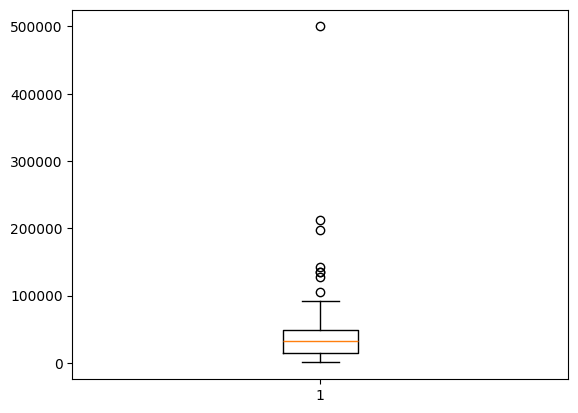

In [250]:
plt.boxplot(df['Driven_kms'])
plt.show()

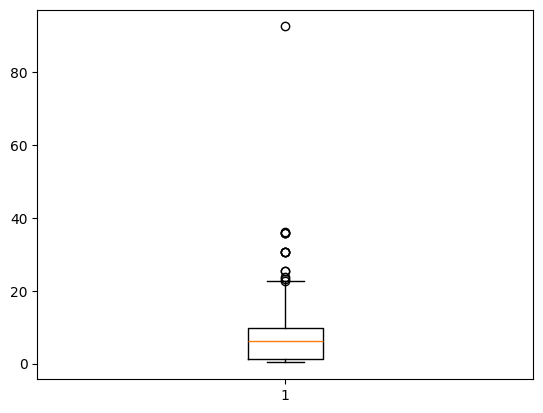

In [251]:
plt.boxplot(df['Present_Price'])
plt.show()

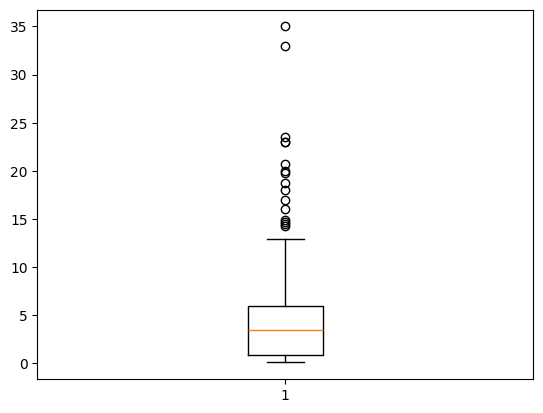

In [252]:
plt.boxplot(df['Selling_Price'])
plt.show()

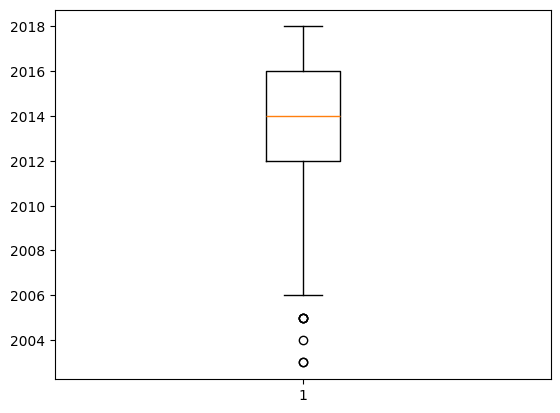

In [253]:
plt.boxplot(df['Year'])
plt.show()

In [254]:
df['Selling_Price'] = np.log(df['Selling_Price'])
df['Present_Price'] = np.log(df['Present_Price'])
df['Driven_kms'] = np.log(df['Driven_kms'])

In [255]:
df['Car_Age'] = 2026 - df['Year']

In [256]:
df['Car_Age'].describe()

,Car_Age
count,299.000000
mean,12.384615
std,2.896868
min,8.000000
25%,10.000000
50%,12.000000
75%,14.000000
max,23.000000


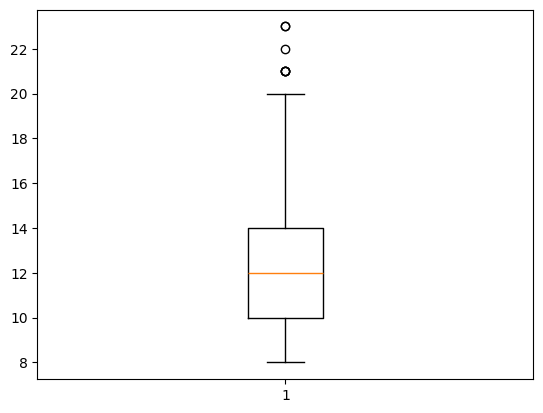

In [257]:
plt.boxplot(df['Car_Age'])
plt.show()

In [258]:
df['Brand'] = df['Car_Name'].str.strip().apply(lambda x: x.split()[0])
df['km_per_year'] = df['Driven_kms'] / (df['Car_Age'] + 1)

In [259]:
len(df['Brand'].unique())

44

In [260]:
df['Is_Manual'] = df['Transmission'].replace({'Automatic':0, 'Manual':1})
df['By_Dealer'] = df['Selling_type'].replace({'Dealer':1, 'Individual':0})

/tmp/ipykernel_9775/248654973.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Is_Manual'] = df['Transmission'].replace({'Automatic':0, 'Manual':1})
/tmp/ipykernel_9775/248654973.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['By_Dealer'] = df['Selling_type'].replace({'Dealer':1, 'Individual':0})


In [261]:
df.drop(['Year', 'Selling_type', 'Transmission', 'Car_Name'], axis=1, inplace=True)

In [262]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Owner,Car_Age,Brand,km_per_year,Is_Manual,By_Dealer
0,1.208960,1.720979,10.203592,Petrol,0,12,ritz,0.784892,1,1
1,1.558145,2.255493,10.668955,Diesel,0,13,sx4,0.762068,1,1
2,1.981001,2.287471,8.839277,Petrol,0,9,ciaz,0.883928,1,1
3,1.047319,1.423108,8.556414,Petrol,0,15,wagon,0.534776,1,1
4,1.526056,1.927164,10.656082,Diesel,0,12,swift,0.819699,1,1


In [263]:
X = df.drop(['Selling_Price'], axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [264]:
brand_mean = X_train.groupby('Brand')['Present_Price'].mean()

X_train['brand_goodwill'] = X_train['Brand'].map(brand_mean)
X_test['brand_goodwill'] = X_test['Brand'].map(brand_mean)

X_test['brand_goodwill'].fillna(X_train['brand_goodwill'].mean(), inplace=True)

/tmp/ipykernel_9775/4071715932.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['brand_goodwill'].fillna(X_train['brand_goodwill'].mean(), inplace=True)


In [265]:
X_train = X_train.drop(['Brand'], axis=1)
X_test = X_test.drop(['Brand'], axis=1)

In [266]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_cat = ohe.fit_transform(X_train[['Fuel_Type']])
X_test_cat = ohe.transform(X_test[['Fuel_Type']])

In [267]:
num_cols = X_train.drop(['Fuel_Type'], axis=1).to_numpy()
num_cols_test = X_test.drop(['Fuel_Type'], axis=1).to_numpy()

In [268]:
X_train = np.concatenate([num_cols, X_train_cat], axis=1)
X_test = np.concatenate([num_cols_test, X_test_cat], axis=1)

In [269]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [270]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [271]:
multi_lr = LinearRegression()
multi_lr.fit(X_train, y_train)

LinearRegression()

In [272]:
y_pred_multi = multi_lr.predict(X_test)
mae_m = mean_absolute_error(y_test, y_pred_multi)
mse_m = mean_squared_error(y_test, y_pred_multi)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test, y_pred_multi)
print(f"Multiple LR — MAE: {mae_m:.2f}, MSE: {mse_m:.2f}, RMSE: {rmse_m:.2f}, R2: {r2_m:.4f}")

Multiple LR — MAE: 0.16, MSE: 0.04, RMSE: 0.20, R2: 0.9758


In [273]:
train_r2 = multi_lr.score(X_train, y_train)
test_r2 = multi_lr.score(X_test, y_test)
print(f"Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")

Train R²: 0.9819, Test R²: 0.9758


In [274]:
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mae_l1 = mean_absolute_error(y_test, y_pred_lasso)
mse_l1 = mean_squared_error(y_test, y_pred_lasso)
rmse_l1 = np.sqrt(mse_l1)
r2_l1 = r2_score(y_test, y_pred_lasso)
print(f"Lasso — MAE: {mae_l1:.2f}, RMSE: {rmse_l1:.2f}, R2: {r2_l1:.4f}")

Lasso — MAE: 0.23, RMSE: 0.31, R2: 0.9449


In [275]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mae_l2 = mean_absolute_error(y_test, y_pred_ridge)
mse_l2 = mean_squared_error(y_test, y_pred_ridge)
rmse_l2 = np.sqrt(mse_l2)
r2_l2 = r2_score(y_test, y_pred_ridge)
print(f"Ridge — MAE: {mae_l2:.2f}, RMSE: {rmse_l2:.2f}, R2: {r2_l2:.4f}")

Ridge — MAE: 0.16, RMSE: 0.20, R2: 0.9756


In [276]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)
mae_en = mean_absolute_error(y_test, y_pred_elastic)
mse_en = mean_squared_error(y_test, y_pred_elastic)
rmse_en = np.sqrt(mse_en)
r2_en = r2_score(y_test, y_pred_elastic)
print(f"Elastic Net — MAE: {mae_en:.2f}, RMSE: {rmse_en:.2f}, R2: {r2_en:.4f}")

Elastic Net — MAE: 0.20, RMSE: 0.25, R2: 0.9634


In [279]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso', 'Ridge','Elastic'],
    'MAE': [mae_m, mae_l1, mae_l2, mae_en],
    'RMSE': [rmse_m, rmse_l1, rmse_l2, rmse_en],
    'R2': [r2_m, r2_l1, r2_l2, r2_en]
})
print(results)

               Model       MAE      RMSE        R2
0  Linear Regression  0.162641  0.203879  0.975761
1              Lasso  0.227563  0.307415  0.944891
2              Ridge  0.161982  0.204477  0.975618
3            Elastic  0.195807  0.250640  0.963367


In [287]:
expected_features = scaler.n_features_in_
print(f"Feasures expected from scaler: {expected_features}")

fuel_column_names = ohe.get_feature_names_out(['Fuel_Type'])
print(f"Columns of Fuel_Type: {fuel_column_names}")

Feasures expected from scaler: 11
Columns of Fuel_Type: ['Fuel_Type_CNG' 'Fuel_Type_Diesel' 'Fuel_Type_Petrol']


In [291]:
print("\n" + "="*50)
print("Car Price Prediction System")
print("="*50)

print("\nPlease enter the car details:")

present_price = float(input("   Current price of the car (in thousands): "))
driven_kms = float(input("   Total kilometers driven: "))
fuel_type = input("   Fuel type (Petrol/Diesel/CNG): ")
owner = int(input("   Number of previous owners (0,1,2,3): "))
car_age = int(input("   Car age in years: "))
transmission = input("   Transmission type (Manual/Automatic): ")
selling_type = input("   Selling type (Dealer/Individual): ")

is_manual = 1 if transmission.lower() == 'manual' else 0
by_dealer = 1 if selling_type.lower() == 'dealer' else 0

km_per_year = driven_kms / (car_age + 1)

print(f"\n(Automatically calculated average km/year: {km_per_year:.0f})")

new_car_df = pd.DataFrame([{
    'Present_Price': present_price,
    'Driven_kms': driven_kms,
    'Fuel_Type': fuel_type,
    'Owner': owner,
    'Car_Age': car_age,
    'km_per_year': km_per_year,
    'Is_Manual': is_manual,
    'By_Dealer': by_dealer
}])

fuel_encoded = ohe.transform(new_car_df[['Fuel_Type']])

numeric_cols = ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'km_per_year', 'Is_Manual', 'By_Dealer']
numeric_data = new_car_df[numeric_cols].to_numpy()

final_data = np.concatenate([numeric_data, fuel_encoded], axis=1)

print(f"\nNumber of features in input: {final_data.shape[1]}")
print(f"Expected scaler features: {scaler.n_features_in_}")

if final_data.shape[1] < scaler.n_features_in_:
    missing_cols = scaler.n_features_in_ - final_data.shape[1]
    zeros_to_add = np.zeros((final_data.shape[0], missing_cols))
    final_data = np.concatenate([final_data, zeros_to_add], axis=1)
elif final_data.shape[1] > scaler.n_features_in_:
    final_data = final_data[:, :scaler.n_features_in_]

final_data_scaled = scaler.transform(final_data)

predicted_price_log = multi_lr.predict(final_data_scaled)[0]
predicted_price_real = np.exp(predicted_price_log)

print("\n" + "="*50)
print(f"Predicted selling price: {predicted_price_real:,.2f} thousand")
print(f"= {predicted_price_real * 1000:,.0f} EGP")
print("="*50)


Car Price Prediction System

Please enter the car details:
   Current price of the car (in thousands): 7
   Total kilometers driven: 23
   Fuel type (Petrol/Diesel/CNG): Diesel
   Number of previous owners (0,1,2,3): 2
   Car age in years: 18
   Transmission type (Manual/Automatic): Manual
   Selling type (Dealer/Individual): Dealer

(Automatically calculated average km/year: 1)

Number of features in input: 10
Expected scaler features: 11

Predicted selling price: 38.88 thousand
= 38,875 EGP
